# Logistic Regression — Implementation and Evaluation

**Dataset:** Breast Cancer Wisconsin (scikit-learn)  
**Goal:** Train a binary logistic regression classifier and evaluate it using confusion matrix, accuracy, precision, recall, and F1 score.

**Prerequisites:**
- Basic Python and pandas knowledge
- Understanding of what classification means — predicting a category, not a number
- No prior ML experience needed — everything is explained as we go

**Pipeline overview:**
1. Load and identify the dataset
2. Build a DataFrame
3. Check missing values
4. Examine feature correlation
5. Separate features and target
6. Train/test split
7. Feature scaling
8. Fit the model
9. Predict on test data
10. Calculate metrics
11. Confusion matrix

## Step 1 — Load and Identify the Dataset

**What goes in:** Nothing — we load directly from scikit-learn's built-in datasets.  
**What comes out:** A scikit-learn `Bunch` object — not a DataFrame yet.  
**Why:** We need to understand what `load_breast_cancer()` actually returns before we can work with it. Beginners often assume it returns a DataFrame — it doesn't.

**Assumption:** scikit-learn is installed (`pip install scikit-learn`)

In [7]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
print(type(data))  # Not a DataFrame — it's a scikit-learn Bunch object

<class 'sklearn.utils._bunch.Bunch'>


**Output explained:**  
`<class 'sklearn.utils._bunch.Bunch'>` — a dictionary-like object with fixed keys.  
Always check the type of a new data object before assuming what methods are available.

**What's inside the Bunch object:**

| Key | What it contains |
|---|---|
| `data.data` | Feature values — a NumPy array of shape (569, 30) |
| `data.target` | Target values — 0s and 1s |
| `data.feature_names` | Names of the 30 feature columns |
| `data.target_names` | Class names — `['malignant', 'benign']` |
| `data.DESCR` | Full description of the dataset |

In [8]:
print(f"data type         = {type(data.data)}")
print(f"data shape        = {data.data.shape}")
print(f"feature names     = {data.feature_names}")
print(f"target names      = {data.target_names}")
print(f"dataset keys      = {data.keys()}")

data type         = <class 'numpy.ndarray'>
data shape        = (569, 30)
feature names     = ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
target names      = ['malignant' 'benign']
dataset keys      = dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


**Output explained:**  
- `data shape = (569, 30)` — 569 patients, 30 measurements each  
- `feature names` — all 30 column names, grouped as mean, error, and worst versions  
- `target names = ['malignant' 'benign']` — 0 = malignant, 1 = benign  
- `dataset keys` — everything available inside the Bunch object

---

## Step 2 — Build the DataFrame

**What goes in:** `data.data` (NumPy array) + `data.feature_names` (column names) + `data.target` (labels)  
**What comes out:** A pandas DataFrame with 569 rows and 31 columns (30 features + target)  
**Why:** pandas DataFrame is easier to work with than a raw NumPy array — it has named columns, easy inspection methods, and works well with scikit-learn.

**Key line:** `pd.DataFrame(data.data, columns=data.feature_names)`  
- `data.data` = the table body (numbers)  
- `data.feature_names` = the header row (column names)

In [9]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


**Output explained:**  
First 5 rows of the dataset. Check:
- Do the column names make sense?
- Are the values in a reasonable range?
- Is the target column (0 or 1) at the end?

---

## Step 3 — Check Missing Values

**What goes in:** The full DataFrame `df`  
**What comes out:** A count of missing values per column  
**Why:** Missing values break most ML models. Always check before training.

**Two ways to check:**
- `df.isnull()` → full True/False table per cell — hard to read across 569 rows
- `df.isnull().sum()` → one number per column — easy to read. `0` = no missing values

In [10]:
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

**Output explained:**  
All zeros — no missing values anywhere. This dataset is clean.  
In real-world datasets you would see non-zero values here and would need to handle them (fill with mean, drop rows, etc.) before training.

---

## Step 4 — Examine Feature Correlation

**What goes in:** The DataFrame without the target column  
**What comes out:** A 30×30 correlation matrix visualised as a heatmap  
**Why:** Highly correlated features give the model the same information twice. For logistic regression this causes multicollinearity — unstable weights. Checking correlation helps decide if any features should be dropped or combined.

**How to read the heatmap:**
- Diagonal is always 1.0 — every feature perfectly correlated with itself, always darkest
- Dark red off-diagonal = strong positive correlation → potential redundancy
- Light/white = weak correlation → independent information
- Dark blue = strong negative correlation

**Assumption:** seaborn is installed (`pip install seaborn`)

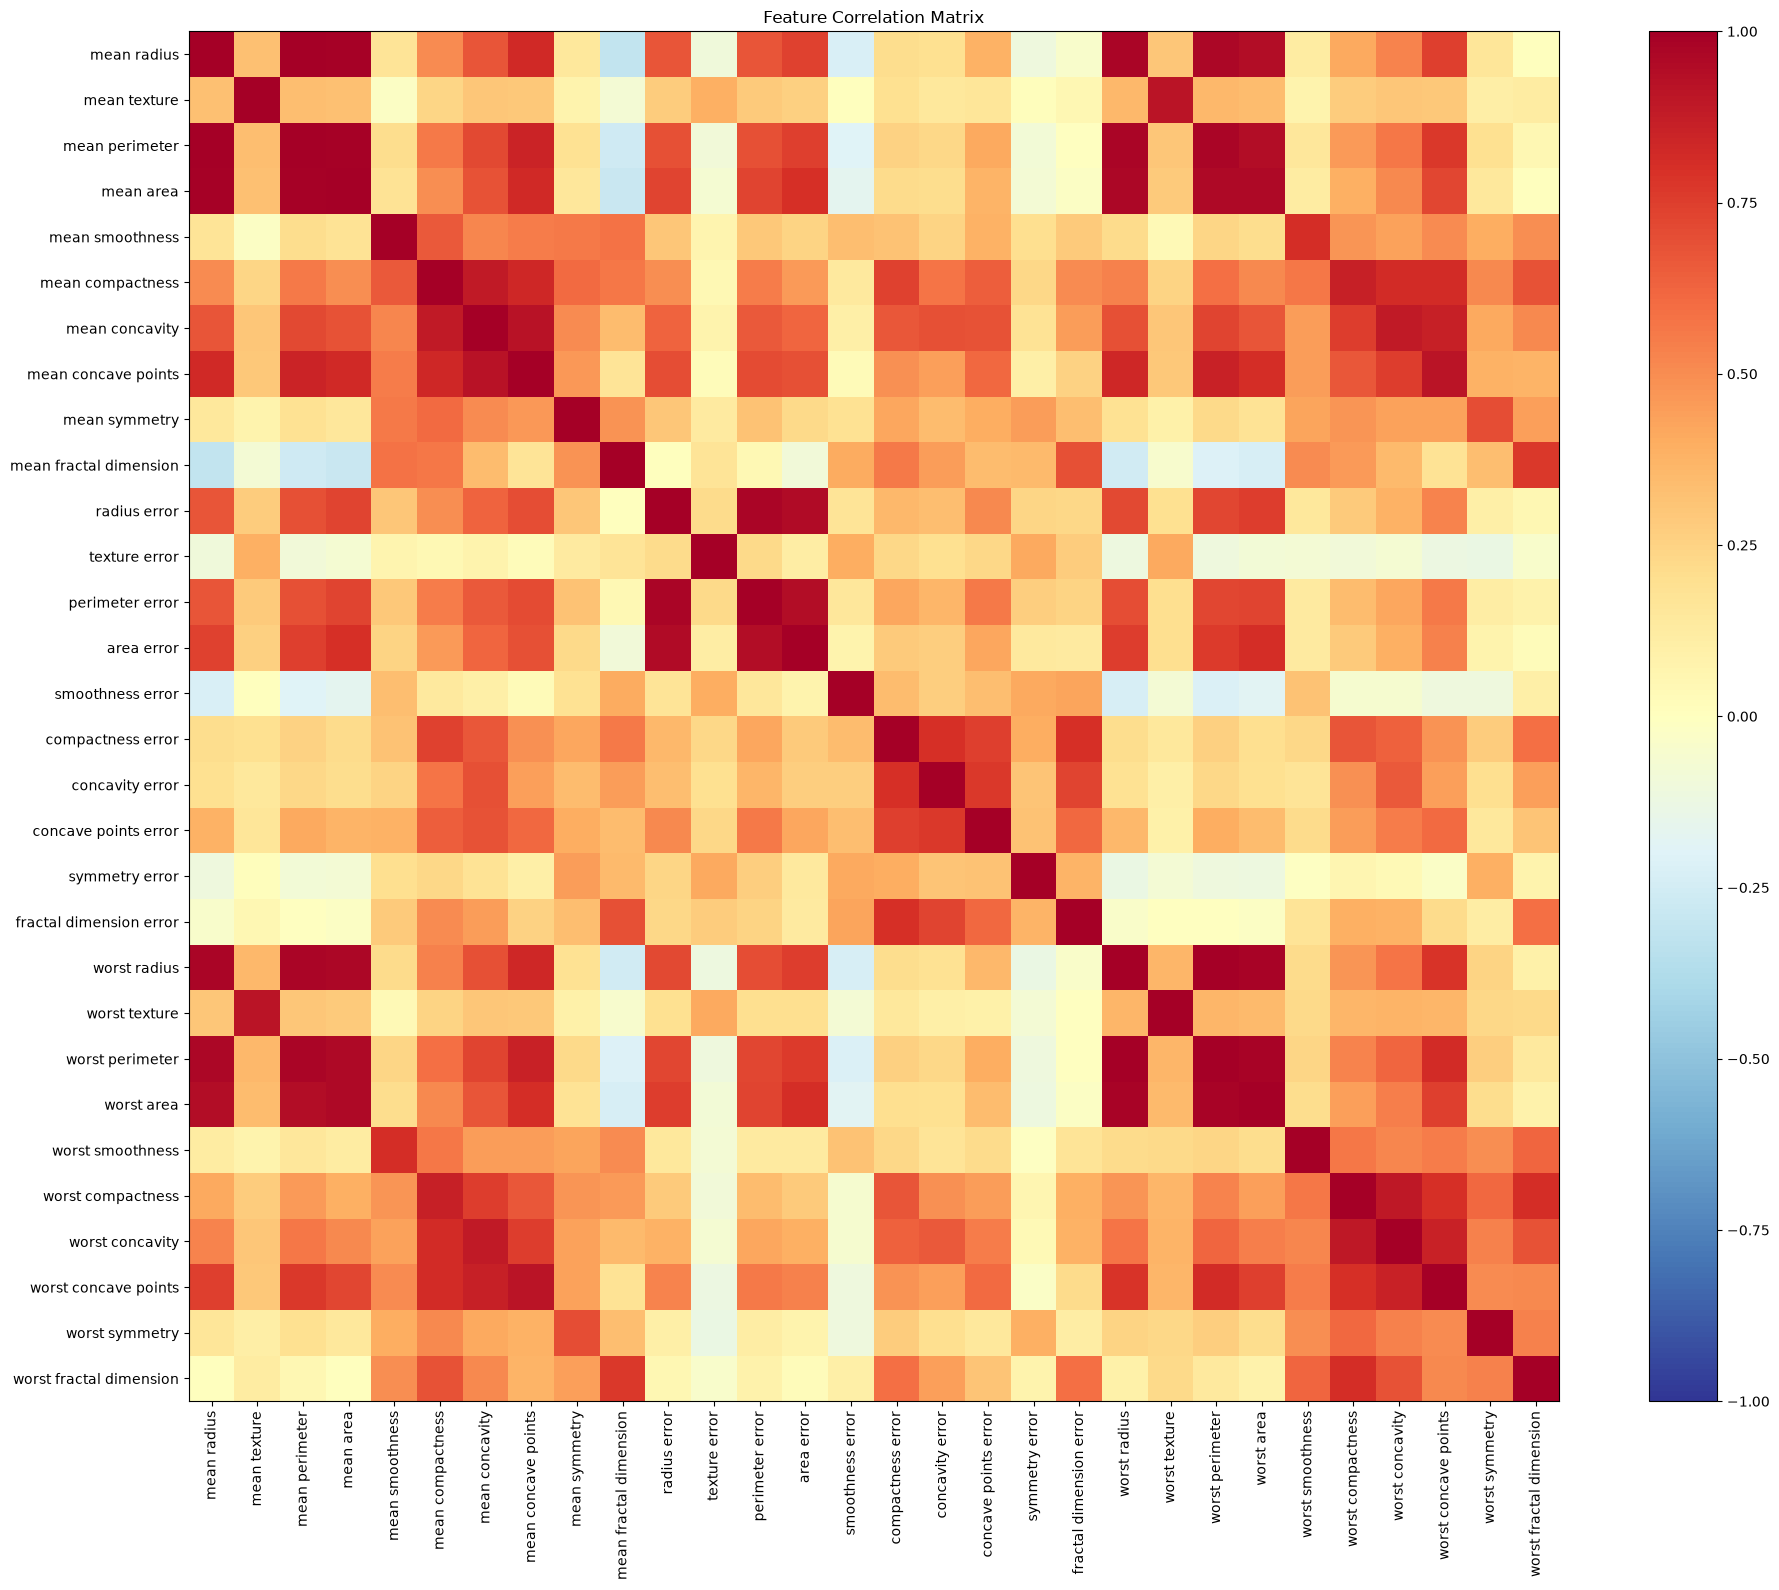

In [11]:
import matplotlib.pyplot as plt

corr_matrix = df.drop(columns=['target']).corr()

plt.figure(figsize=(20, 16))
plt.imshow(corr_matrix, cmap='RdYlBu_r', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

**Output explained:**  
Three dark red clusters are visible:
- **Top-left** — mean radius, mean perimeter, mean area (0.95–0.99) — strong redundancy
- **Middle** — error versions of the same features
- **Bottom-right** — worst versions of the same features

The dataset repeats the same measurements three times (mean, error, worst).  
For this notebook we keep all features — the goal is evaluation, not feature engineering.

---

## Step 5 — Separate Features and Target

**What goes in:** Full DataFrame `df`  
**What comes out:** `X` — feature matrix (569 × 30), `y` — target vector (569,)  
**Why:** scikit-learn models expect features and target as separate inputs.

**Convention:**  
- `X` is capital — represents a **matrix** (2D). Matrices are capitals in linear algebra.  
- `y` is lowercase — represents a **vector** (1D). Vectors are lowercase in linear algebra.

In [12]:
X = df.drop(columns=['target'])
y = df['target']

print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")

Features shape : (569, 30)
Target shape   : (569,)


**Output explained:**  
- `X.shape = (569, 30)` — 569 patients, 30 features each  
- `y.shape = (569,)` — 569 labels, one per patient, no second dimension

---

## Step 6 — Train/Test Split

**What goes in:** `X` and `y`  
**What comes out:** 4 sets — `X_train`, `X_test`, `y_train`, `y_test`  
**Why:** We train on one portion and evaluate on a completely separate portion the model has never seen. This tells us how well the model generalises to new data.

**Key parameters:**
- `test_size=0.2` — 20% goes to test (114 rows), 80% to train (455 rows)
- `random_state=42` — fixes the random seed so the split is reproducible
- `stratify=y` — preserves the original class proportions in both splits. Without this, a random split might give the test set a skewed class distribution, making evaluation unreliable.

**Rule:** Always split before scaling — scaling after prevents data leakage.

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

X_train shape: (455, 30)
X_test shape:  (114, 30)
y_train shape: (455,)
y_test shape:  (114,)


**Output explained:**  
- `X_train = (455, 30)` — 80% of 569 patients for training  
- `X_test = (114, 30)` — 20% of 569 patients for evaluation  
- Both y sets match their X counterparts row for row

---

## Step 7 — Feature Scaling

**What goes in:** `X_train` and `X_test`  
**What comes out:** `X_train_scaled` and `X_test_scaled` — same shape, values normalised  
**Why:** Logistic regression uses gradient descent internally. Features on very different scales (mean radius: 6–28 vs mean area: 143–2501) cause the model to learn unevenly. Scaling puts all features on the same scale.

**StandardScaler:** subtracts the mean and divides by standard deviation.  
After scaling: mean ≈ 0, std ≈ 1 for every feature.

**Critical rule — fit on train, transform both:**
- `fit_transform(X_train)` — learns mean and std from training data, then applies it
- `transform(X_test)` — applies the already-learned scaling to test data, never refits

**Never fit on test data** — that would leak test information into the scaler.  
**Never scale y** — y is a class label (0 or 1), not a measurement.

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data only, then apply to both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Sanity checks
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_train_scaled mean (should be ~0): {X_train_scaled.mean().round(2)}")
print(f"X_train_scaled std  (should be ~1): {X_train_scaled.std().round(2)}")

X_train_scaled shape: (455, 30)
X_train_scaled mean (should be ~0): 0.0
X_train_scaled std  (should be ~1): 1.0


**Output explained:**  
- Shape unchanged — scaling never changes the number of rows or columns  
- Mean ≈ 0 and std ≈ 1 confirms scaling worked correctly

---

## Step 8 — Fit the Model

**What goes in:** `X_train_scaled` and `y_train`  
**What comes out:** A trained logistic regression model  
**Why:** `model.fit()` runs the training process — it finds the weights (coefficients) that best separate the two classes using the training data.

**Key parameter:**
- `random_state=42` — makes results reproducible

In [15]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

print(f"Model trained successfully")
print(f"Classes: {model.classes_}")

Model trained successfully
Classes: [0 1]


**Output explained:**  
- `Model trained successfully` — `fit()` completed without errors  
- `Classes: [0 1]` — confirms the model found two classes: 0 (malignant) and 1 (benign)

---

## Step 9 — Predict on Test Data

**What goes in:** `X_test_scaled` — the scaled test features  
**What comes out:** `y_pred` — predicted class labels (0 or 1) for each test patient  
**Why:** We run the trained model on data it has never seen to get its predictions. Comparing these to `y_test` tells us how well the model performs.

**Important:** Always use `X_test_scaled` (scaled), not `X_test` (unscaled). The model was trained on scaled data — using unscaled data would give wrong results.

In [16]:
y_pred = model.predict(X_test_scaled)

print(f"Predictions: {y_pred}")
print(f"Actual:      {y_test.values}")
print(f"Total predictions: {len(y_pred)}")

Predictions: [0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 0 0 1
 1 1 0 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 1 1 0
 0 0 0 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 1 0 1
 0 1 1]
Actual:      [0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 1 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 0 0 1
 1 1 0 1 1 1 0 0 1 1 1 1 0 1 1 1 0 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 1 1 0
 0 0 0 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 1 0 1
 0 1 1]
Total predictions: 114


**Output explained:**  
114 predictions — one per test patient. Most values match between predictions and actual. The differences are the model's mistakes. Eyeballing 114 numbers is hard — the next two steps summarise this clearly.

---

## Step 10 — Classification Metrics

**What goes in:** `y_test` (actual labels) and `y_pred` (predicted labels)  
**What comes out:** Four numbers — accuracy, precision, recall, F1  
**Why:** A single metric never tells the full story. Each metric measures a different aspect of model performance.

**What each metric means:**

| Metric | Question it answers |
|---|---|
| Accuracy | Out of all patients, how many did the model get right? |
| Precision | Of all patients predicted benign, how many actually were? |
| Recall | Of all actual benign patients, how many did the model catch? |
| F1 Score | Balance between precision and recall — single combined score |

**In medical context:** Recall matters most — missing a real cancer case (False Negative) is far more dangerous than a false alarm.

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

Accuracy:  0.9825
Precision: 0.9861
Recall:    0.9861
F1 Score:  0.9861


**Output explained:**  
- Accuracy 98.25% — 112 out of 114 correct  
- Precision 98.61% — when the model predicts benign, it's right 98.61% of the time  
- Recall 98.61% — the model caught 98.61% of all actual benign cases  
- F1 98.61% — precision and recall are equal here, so F1 equals both

---

## Step 11 — Confusion Matrix

**What goes in:** `y_test` and `y_pred`  
**What comes out:** A 2×2 grid showing exactly where the model was right and wrong  
**Why:** Metrics give you numbers — the confusion matrix shows you *where* the mistakes are. For medical diagnosis, knowing whether mistakes are False Positives or False Negatives is critical.

**Reading the matrix:**

| | Predicted Malignant | Predicted Benign |
|---|---|---|
| **Actual Malignant** | TN — correct | FP — missed cancer ⚠ |
| **Actual Benign** | FN — false alarm | TP — correct |

- **TN:** Correctly identified malignant  
- **TP:** Correctly identified benign  
- **FP:** Said benign — actually malignant. Most dangerous in cancer detection.  
- **FN:** Said malignant — actually benign. Leads to unnecessary tests.

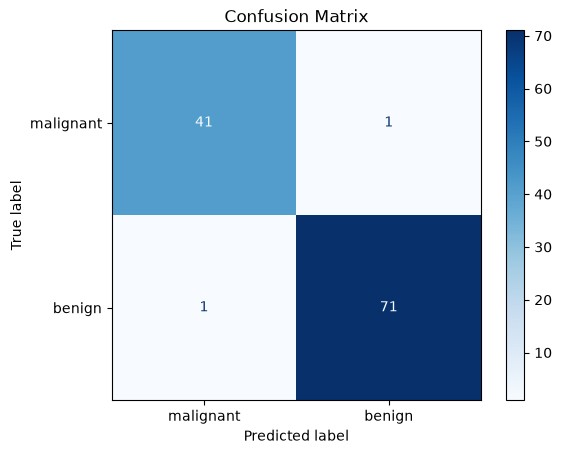

True Negatives  (TN): 41
False Positives (FP): 1
False Negatives (FN): 1
True Positives  (TP): 71


In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

print(f"True Negatives  (TN): {cm[0][0]}")
print(f"False Positives (FP): {cm[0][1]}")
print(f"False Negatives (FN): {cm[1][0]}")
print(f"True Positives  (TP): {cm[1][1]}")

**Output explained:**  
- TN: 41 — 41 malignant patients correctly identified  
- TP: 71 — 71 benign patients correctly identified  
- FP: 1 — 1 malignant patient missed — model said benign but was malignant  
- FN: 1 — 1 benign patient wrongly flagged — model said malignant but was benign  

Only 2 mistakes out of 114. The dangerous mistake (FP — missed cancer) is just 1 case.